In [ ]:
import jax
import jax.numpy as jnp
import jax.scipy as jsp
import jax.random as jr
import jax.scipy.special as jss
import healpy as hp
import astropy as ap
from astropy.coordinates import SkyCoord
from dustmaps.edenhofer2023 import Edenhofer2023Query
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
import matplotlib.pyplot as plt

jax.config.update("jax_enable_x64", True)

def general_matern_spectral_density(omega, inference_params, jitter = 1e-6):
        logvar, logscale, lognu = inference_params
        nu = jnp.exp(lognu)
        log_ratio = jss.gammaln(nu + 0.5) - jss.gammaln(nu)
        r = jnp.square(omega) * jnp.exp(2 * logscale - jnp.log(2.0) - lognu)
        logdensity = logvar + log_ratio - 0.5*jnp.log(2*nu) + logscale - (nu + 0.5)*jnp.log1p(r)
        result = 2*jnp.sqrt(jnp.pi)*jnp.exp(logdensity)
        return result


def matern_magnitude(omega, inference_params):
    return jnp.sqrt(general_matern_spectral_density(omega, inference_params))

def get_omegas(L, N):
     return 2*jnp.pi*jnp.fft.fftfreq(N, d = L/N)



def fft_field_hartley(noise, fourier_length, num_fourier_entries, num_entries, inference_params):
    size = noise.shape[0]
    omegas = get_omegas(fourier_length, num_fourier_entries)
    raw_average_amplitude_data = matern_magnitude(omegas, inference_params)
    normalization_factor = num_fourier_entries/jnp.sqrt(fourier_length)
    H = noise * raw_average_amplitude_data         
    y_data = (hartley(H) / size) * normalization_factor
    return y_data[0:num_entries]

def hartley(x):
    X = jnp.fft.fft(x)
    return jnp.real(X) - jnp.imag(X)

def fold_spectrum(X):
    N = X.shape[0]
    m = N // 2 + 1
    full_fold = ((X + jnp.roll(X[::-1], 1)) / 2)[:m]
    return full_fold[1:]

def get_spectrum(field, fourier_length, num_fourier_entries):
    normalization_factor = num_fourier_entries/jnp.sqrt(fourier_length)
    omegas = get_omegas(fourier_length, num_fourier_entries)
    spectra_with_noise = hartley(field)/normalization_factor
    log_spectrum = jnp.log(fold_spectrum(spectra_with_noise**2))
    log_omegas = jnp.log(fold_spectrum(jnp.abs(omegas)))
    slope, intercept = jnp.polyfit(log_omegas, log_spectrum, 1)
    return log_omegas, log_spectrum, slope, intercept


def get_spectrum2(field, fourier_length, num_fourier_entries):
    normalization_factor = num_fourier_entries/jnp.sqrt(fourier_length)
    omegas = get_omegas(fourier_length, num_fourier_entries)
    spectra_with_noise = jnp.fft.fft(field)/normalization_factor
    log_spectrum = jnp.log(fold_spectrum(jnp.abs(spectra_with_noise)**2))
    log_omegas = jnp.log(fold_spectrum(jnp.abs(omegas)))
    slope, intercept = jnp.polyfit(log_omegas, log_spectrum, 1)
    return log_omegas, log_spectrum, slope, intercept

In [29]:
with fits.open("samples_healpix.fits") as hdul:
    hdul.info()
    pix = hp.pixelfunc.ang2pix(256, theta=0.0, phi=0.0, nest=True, lonlat=True)
    samples_gc = hdul["SAMPLES"].data[:, :, pix]          
    radii = hdul["radial pixel centers"].data["radial pixel centers"]  

with fits.open("../mean_and_std_healpix.fits") as hdul:
    hdul.info()
    galactic_center_healpix = hp.pixelfunc.ang2pix(256, theta = 0.0, phi = 0.0, nest = True, lonlat = True)
    mean_dust_data_along_galactic_center = hdul["MEAN"].data[:, galactic_center_healpix]
    std_dust_data_along_galactic_center = hdul["STD."].data[:, galactic_center_healpix]
    healpix_size = hdul["MEAN"].data[0, :].size
    data_x = hdul['RADIAL PIXEL CENTERS'].data.field(0)
    distance_boundaries = hdul['RADIAL PIXEL BOUNDARIES'].data.field(0)
    distance_gaps = np.diff(distance_boundaries)
    integrated_dust = np.dot(distance_gaps, hdul["MEAN"].data)


samples_gc = jnp.asarray(np.ascontiguousarray(samples_gc).astype(np.float32))
mean_dust_data_along_galactic_center = jnp.asarray(np.ascontiguousarray(mean_dust_data_along_galactic_center).astype(np.float32))
log_samples = jnp.log(samples_gc)
radii = jnp.asarray(np.ascontiguousarray(radii).astype(np.float32))



Filename: samples_healpix.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       9   ()      
  1  SAMPLES       1 ImageHDU        21   (786432, 516, 12)   float32   
  2  RADIAL PIXEL CENTERS    1 BinTableHDU     20   516R x 1C   [E]   
  3  RADIAL PIXEL BOUNDARIES    1 BinTableHDU     20   517R x 1C   [E]   
  4  INTEGRATED INNER 68.8 PC    1 ImageHDU        18   (786432, 12)   float32   
Filename: ../mean_and_std_healpix.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       9   ()      
  1  MEAN          1 ImageHDU        19   (786432, 516)   float32   
  2  STD.          1 ImageHDU        19   (786432, 516)   float32   
  3  RADIAL PIXEL CENTERS    1 BinTableHDU     20   516R x 1C   [E]   
  4  RADIAL PIXEL BOUNDARIES    1 BinTableHDU     20   517R x 1C   [E]   
  5  MEAN OF INTEGRATED INNER 68.8 PC    1 ImageHDU        16   (786432,)   float32   
  6  STD. OF INTEGRATED INNER 68.8

Slope of best-fit line on Edenhofer sample is -1.7245512804429366 so nu is 0.3622756402214683
Slope of best-fit line on Edenhofer mean is is -1.9527181207560924 so nu is 0.4763590603780462
Slope of best-fit line with Hanning filter on Edenhofer sample is -1.8548852244170475 so nu is 0.42744261220852375
Slope of best-fit line with Hanning filter on Edenhofer mean is is -2.3741260556705956 so nu is 0.6870630278352978
Slope of best-fit line on control field with nu = 0.2 is is -1.3864275683587524 so nu is 0.19321378417937618


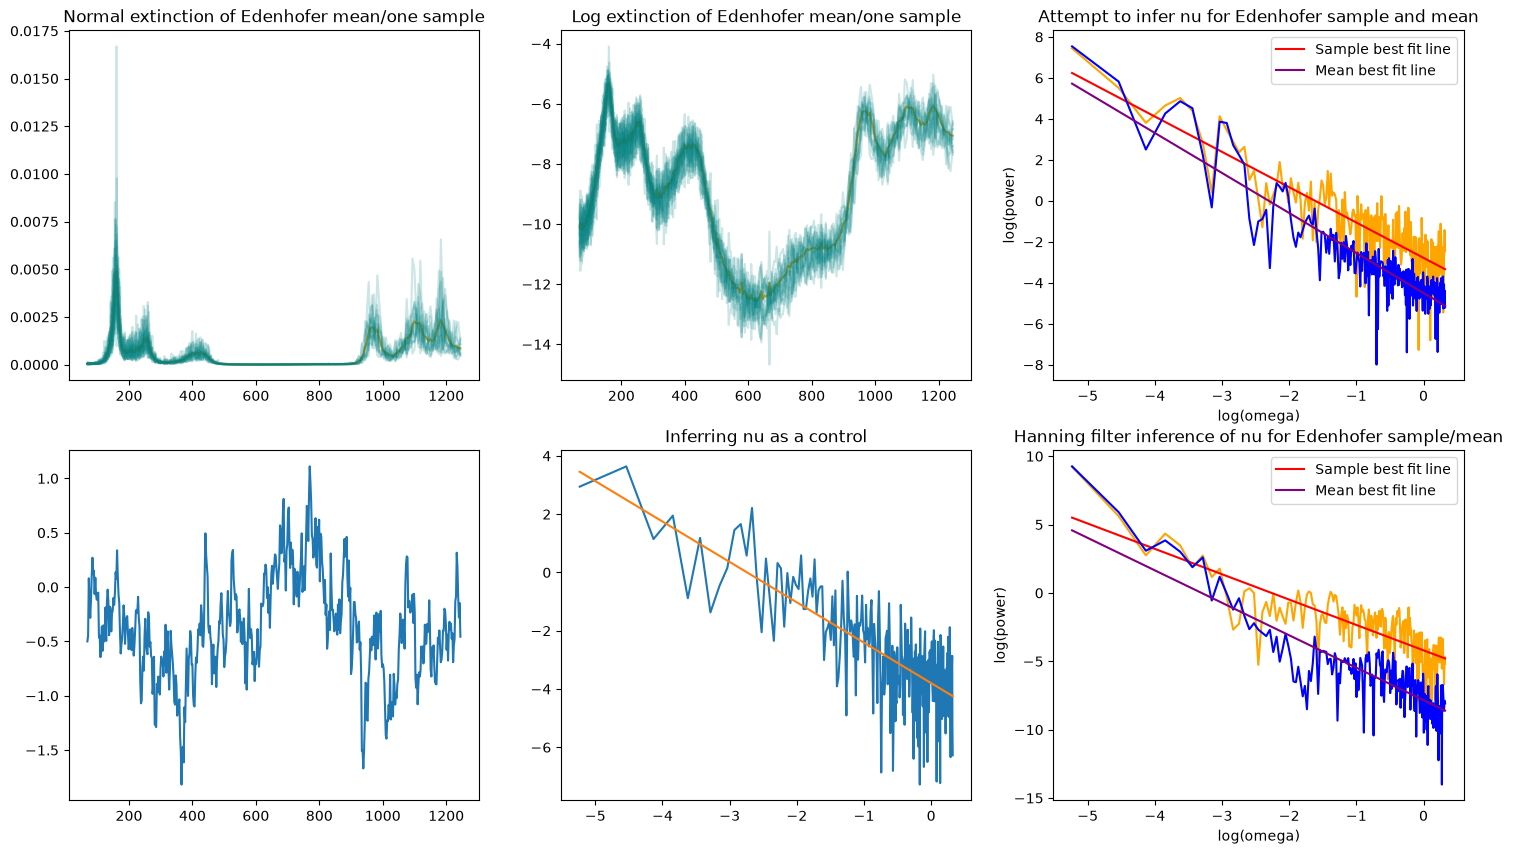

In [87]:
fig, axes = plt.subplots(2, 3, figsize = (18, 10))
axes[0][0].plot(radii, mean_dust_data_along_galactic_center, color = "orange")
axes[0][1].plot(radii, np.log(mean_dust_data_along_galactic_center), color = "orange")
for i in range (0, 12):
    axes[0][0].plot(radii, samples_gc[i, :], color = "teal", alpha = 0.2)
    axes[0][1].plot(radii, log_samples[i, :], color = "teal", alpha = 0.2)

axes[0][0].set_title("Normal extinction of Edenhofer mean/one sample")
axes[0][1].set_title("Log extinction of Edenhofer mean/one sample")
num_dims = radii.size
linspace = jnp.linspace(jnp.min(radii), jnp.max(radii), num_dims)
interp_sample = jnp.interp(linspace, radii, log_samples[0, :])
log_omegas, log_spectrum, slope_sample, intercept = get_spectrum2(interp_sample, jnp.max(radii) - jnp.min(radii), num_dims)
axes[0][2].plot(log_omegas, log_spectrum, color = "orange")
axes[0][2].plot(log_omegas, intercept + slope_sample*log_omegas, color = "red", label = "Sample best fit line")
axes[0][2].set_xlabel("log(omega)")
axes[0][2].set_ylabel("log(power)")

log_omegas, log_spectrum, slope_sample_hanning, intercept = get_spectrum2(interp_sample*jnp.hanning(num_dims), jnp.max(radii) - jnp.min(radii), num_dims)
axes[1][2].plot(log_omegas, log_spectrum, color = "orange")
axes[1][2].plot(log_omegas, intercept + slope_sample_hanning*log_omegas, color = "red", label = "Sample best fit line")
axes[1][2].set_title("Hanning filter inference of nu for Edenhofer sample/mean")
axes[1][2].set_xlabel("log(omega)")
axes[1][2].set_ylabel("log(power)")

interp_mean = jnp.interp(linspace, radii, jnp.log(mean_dust_data_along_galactic_center))
log_omegas, log_spectrum, slope_mean, intercept = get_spectrum2(interp_mean, jnp.max(radii) - jnp.min(radii), num_dims)
axes[0][2].plot(log_omegas, log_spectrum, color = "blue")
axes[0][2].plot(log_omegas, intercept + slope_mean*log_omegas, color = "purple", label = "Mean best fit line")
axes[0][2].set_title("Attempt to infer nu for Edenhofer sample and mean")
axes[0][2].set_xlabel("log(omega)")
axes[0][2].set_ylabel("log(power)")
axes[0][2].legend()


log_omegas, log_spectrum, slope_mean_hanning, intercept = get_spectrum2(interp_mean*jnp.hanning(num_dims), jnp.max(radii) - jnp.min(radii), num_dims)
axes[1][2].plot(log_omegas, log_spectrum, color = "blue")
axes[1][2].plot(log_omegas, intercept + slope_mean_hanning*log_omegas, color = "purple", label = "Mean best fit line")
axes[1][2].set_xlabel("log(omega)")
axes[1][2].set_ylabel("log(power)")
axes[1][2].legend()



rng = jr.PRNGKey(0)
noise = jr.normal(rng, shape = (num_dims,))
length = jnp.max(radii) - jnp.min(radii)
test_field = fft_field_hartley(noise, length, num_dims, num_dims, (jnp.log(1), jnp.log(2*length), jnp.log(0.2)))
axes[1][0].plot(linspace, test_field)
log_omegas, log_spectrum, slope_control, intercept = get_spectrum2(test_field, jnp.max(radii) - jnp.min(radii), num_dims)
axes[1][1].plot(log_omegas, log_spectrum)
axes[1][1].plot(log_omegas, intercept + slope_control*log_omegas)
axes[1][1].set_title("Inferring nu as a control")
print(f"Slope of best-fit line on Edenhofer sample is {slope_sample} so nu is {(-1 - slope_sample)/2.0}")
print(f"Slope of best-fit line on Edenhofer mean is is {slope_mean} so nu is {(-1 - slope_mean)/2.0}")
print(f"Slope of best-fit line with Hanning filter on Edenhofer sample is {slope_sample_hanning} so nu is {(-1 - slope_sample_hanning)/2.0}")
print(f"Slope of best-fit line with Hanning filter on Edenhofer mean is is {slope_mean_hanning} so nu is {(-1 - slope_mean_hanning)/2.0}")
print(f"Slope of best-fit line on control field with nu = 0.2 is is {slope_control} so nu is {(-1 - slope_control)/2.0}")

Full period slope: -4.962713798238802 Cutoff period slope: -1.8321158842898817 Hanning full period slope: -5.005068383547777 Hanning cutoff period slope: -5.221372087690655


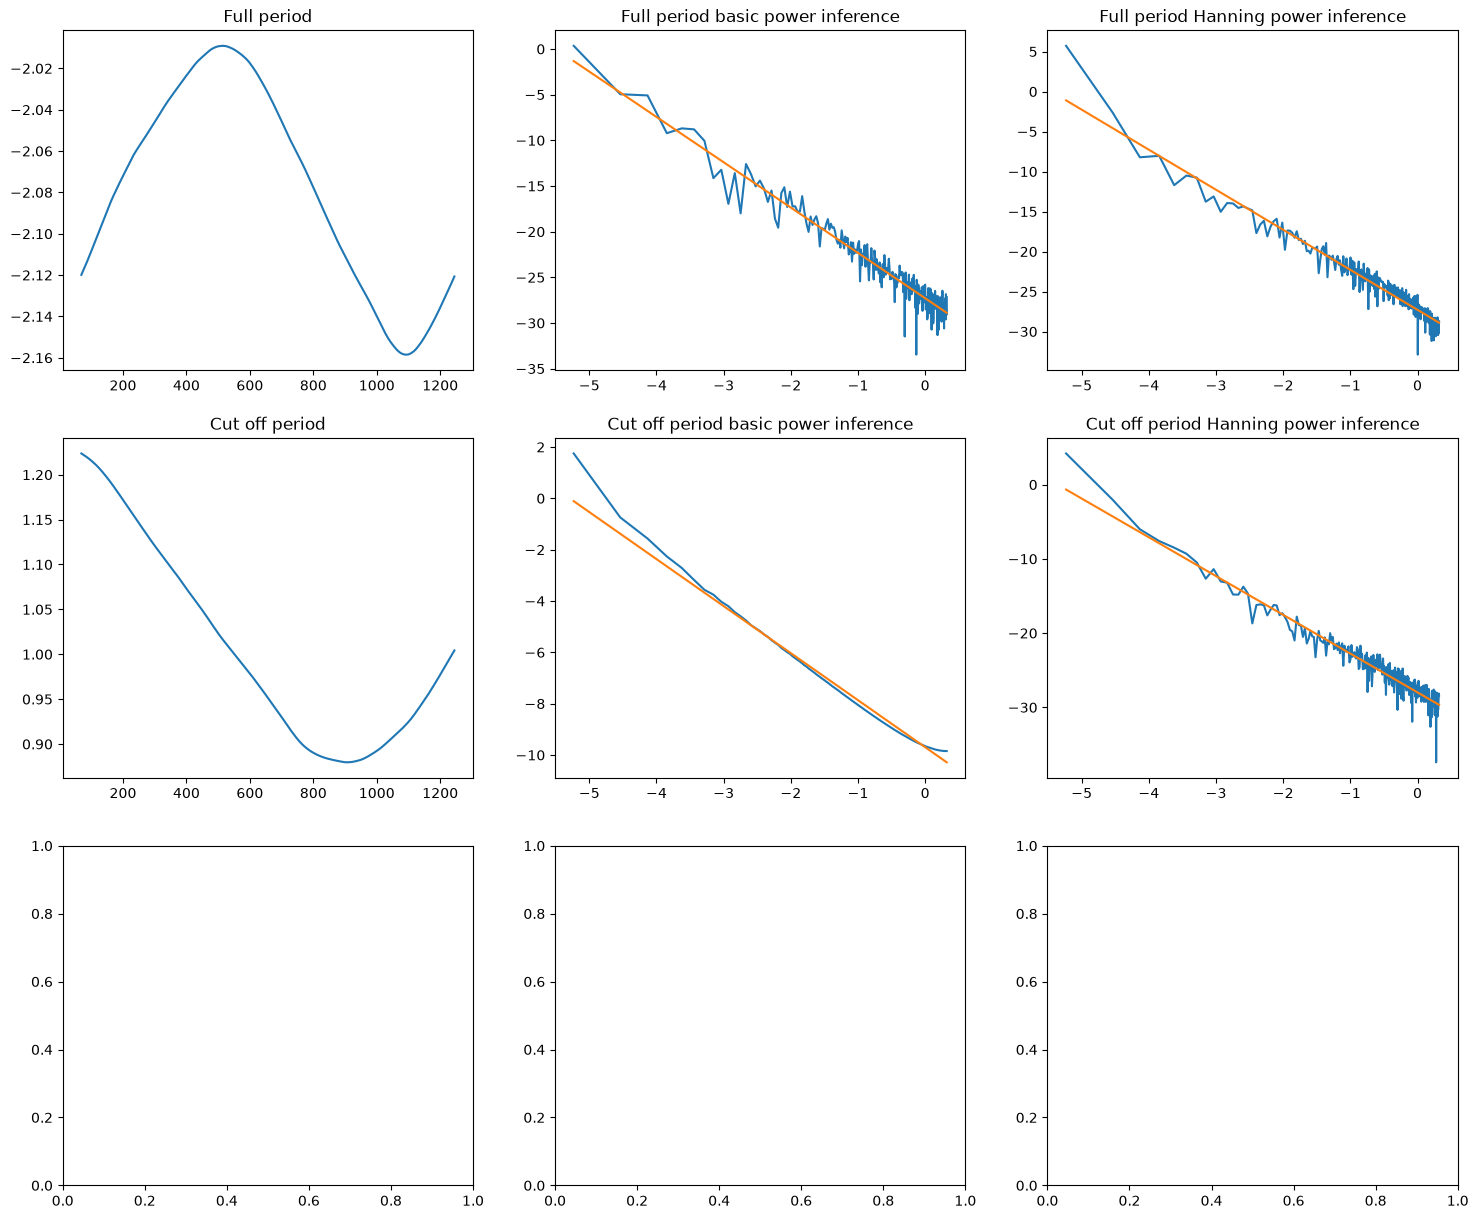

In [85]:
rng = jr.PRNGKey(1)
rng, k1, k2, k3, k4, k5 = jr.split(rng, 6)
noise_1 = jr.normal(k4, shape = (num_dims,))
noise_2 = jr.normal(k2, shape = (10*num_dims,))
test_field = fft_field_hartley(noise_1, length, num_dims, num_dims, (jnp.log(1), jnp.log(2*length), jnp.log(2)))
cut_off_field = fft_field_hartley(noise_2, 10*length, 10*num_dims, num_dims, (jnp.log(1), jnp.log(2*length), jnp.log(2)))

fig, axes = plt.subplots(3, 3, figsize = (18, 15))
log_omegas, log_spectrum, slope_full, intercept = get_spectrum2(test_field, length, num_dims)
axes[0][1].plot(log_omegas, log_spectrum)
axes[0][1].plot(log_omegas, intercept + slope_full*log_omegas)

log_omegas, log_spectrum, slope_cut, intercept = get_spectrum2(cut_off_field, length, num_dims)
axes[1][1].plot(log_omegas, log_spectrum)
axes[1][1].plot(log_omegas, intercept + slope_cut*log_omegas)


axes[0][0].plot(linspace, test_field)
axes[1][0].plot(linspace, cut_off_field)

w = jnp.hanning(num_dims)

log_omegas, log_spectrum, slope_full_hanning, intercept = get_spectrum2(test_field*w, length, num_dims)
axes[0][2].plot(log_omegas, log_spectrum)
axes[0][2].plot(log_omegas, intercept + slope_full_hanning*log_omegas)

log_omegas, log_spectrum, slope_cut_hanning, intercept = get_spectrum2(cut_off_field*w, length, num_dims)
axes[1][2].plot(log_omegas, log_spectrum)
axes[1][2].plot(log_omegas, intercept + slope_cut_hanning*log_omegas)

axes[0][0].set_title("Full period")
axes[0][1].set_title("Full period basic power inference")
axes[0][2].set_title("Full period Hanning power inference")
axes[1][0].set_title("Cut off period")
axes[1][1].set_title("Cut off period basic power inference")
axes[1][2].set_title("Cut off period Hanning power inference")
print(f"Full period slope: {slope_full} Cutoff period slope: {slope_cut} Hanning full period slope: {slope_full_hanning} Hanning cutoff period slope: {slope_cut_hanning}")
